# Task 1: Data dimensionality, distance-based classifiers

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import umap

train_in = np.loadtxt('train_in.csv', delimiter=',')
train_out = np.loadtxt('train_out.csv', delimiter=',').astype(int)
test_in = np.loadtxt('test_in.csv', delimiter=',')
test_out = np.loadtxt('test_out.csv', delimiter=',').astype(int)
print(train_in.shape, test_in.shape)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\NITHIN\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\NITHIN\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\NITHIN\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\NITHIN\AppData\Roaming\Python\Python310\site-packages\traitlets\config\applic

(1707, 256) (1000, 256)


## 1.1 Cloud centers and inter-class distances

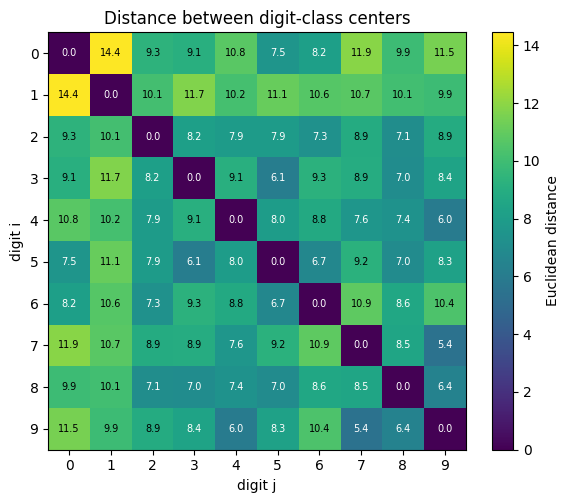

In [ ]:
centers = np.array([train_in[train_out == d].mean(axis=0) for d in range(10)])
dist_matrix = np.linalg.norm(centers[:, None, :] - centers[None, :, :], axis=2)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_matrix, cmap='viridis')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('digit j'); ax.set_ylabel('digit i')
ax.set_title('Distance between digit-class centers')
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{dist_matrix[i,j]:.1f}', ha='center', va='center',
                 color='white' if dist_matrix[i,j] < dist_matrix.max()*0.6 else 'black', fontsize=7)
fig.colorbar(im, ax=ax, label='Euclidean distance')
fig.tight_layout()
plt.show()

In [3]:
pairs = [(dist_matrix[i, j], i, j) for i in range(10) for j in range(i+1, 10)]
pairs.sort()
predicted_pairs = pairs[:5]
print("5 closest center pairs (potentially hardest to separate):")
for d, i, j in predicted_pairs:
    print(f"  digits {i} and {j}: distance = {d:.3f}")

5 closest center pairs (potentially hardest to separate):
  digits 7 and 9: distance = 5.426
  digits 4 and 9: distance = 6.010
  digits 3 and 5: distance = 6.119
  digits 8 and 9: distance = 6.401
  digits 5 and 6: distance = 6.699


## 1.2 Dimensionality reduction: PCA, t-SNE, UMAP

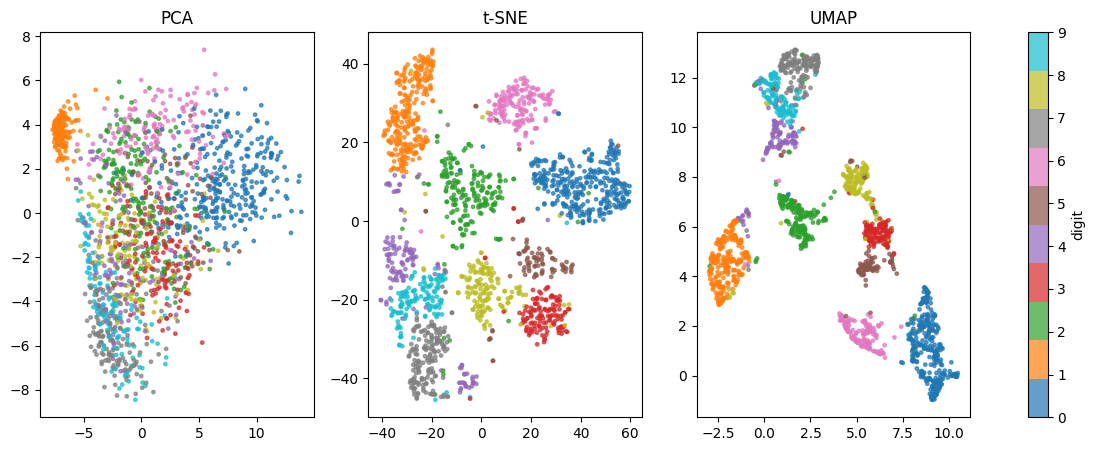

In [ ]:
pca_emb = PCA(n_components=2).fit_transform(train_in)
tsne_emb = TSNE(n_components=2, random_state=0, init='pca').fit_transform(train_in)
umap_emb = umap.UMAP(n_components=2, random_state=0).fit_transform(train_in)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, emb, name in zip(axes, [pca_emb, tsne_emb, umap_emb], ['PCA', 't-SNE', 'UMAP']):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=train_out, cmap='tab10', s=6, alpha=0.7)
    ax.set_title(name)
fig.colorbar(sc, ax=axes, label='digit', ticks=range(10))
plt.show()

## 1.3 Nearest-mean classifier

In [5]:
def nearest_mean_predict(X, centers):
    d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    return d.argmin(axis=1)

nm_train_pred = nearest_mean_predict(train_in, centers)
nm_test_pred = nearest_mean_predict(test_in, centers)
nm_train_acc = accuracy_score(train_out, nm_train_pred)
nm_test_acc = accuracy_score(test_out, nm_test_pred)
print(f"Nearest-mean classifier: train accuracy = {nm_train_acc:.4f}, test accuracy = {nm_test_acc:.4f}")

Nearest-mean classifier: train accuracy = 0.8635, test accuracy = 0.8040


## 1.4 KNN classifier and confusion matrices

In [6]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(train_in, train_out)
knn_train_pred = knn.predict(train_in)
knn_test_pred = knn.predict(test_in)
knn_train_acc = accuracy_score(train_out, knn_train_pred)
knn_test_acc = accuracy_score(test_out, knn_test_pred)
print(f"KNN (k=3) classifier: train accuracy = {knn_train_acc:.4f}, test accuracy = {knn_test_acc:.4f}")

KNN (k=3) classifier: train accuracy = 0.9789, test accuracy = 0.9140


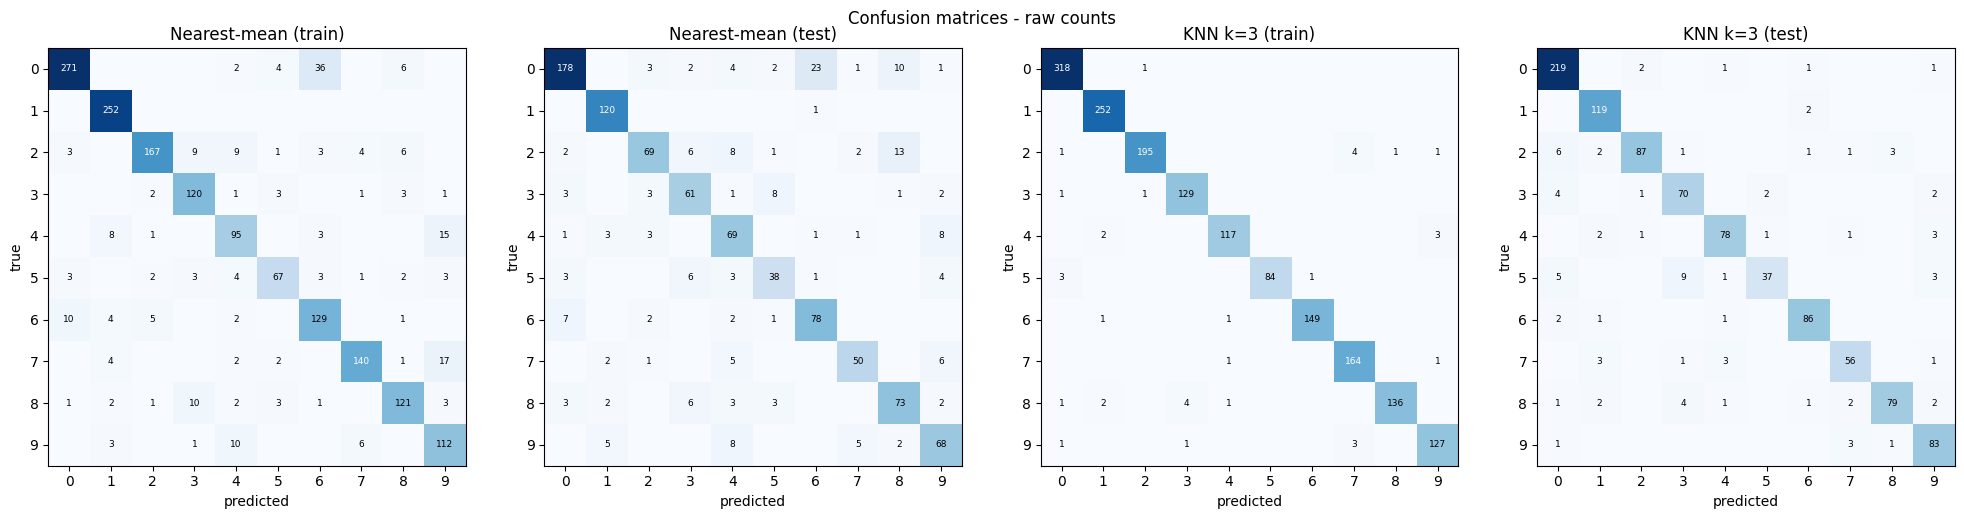

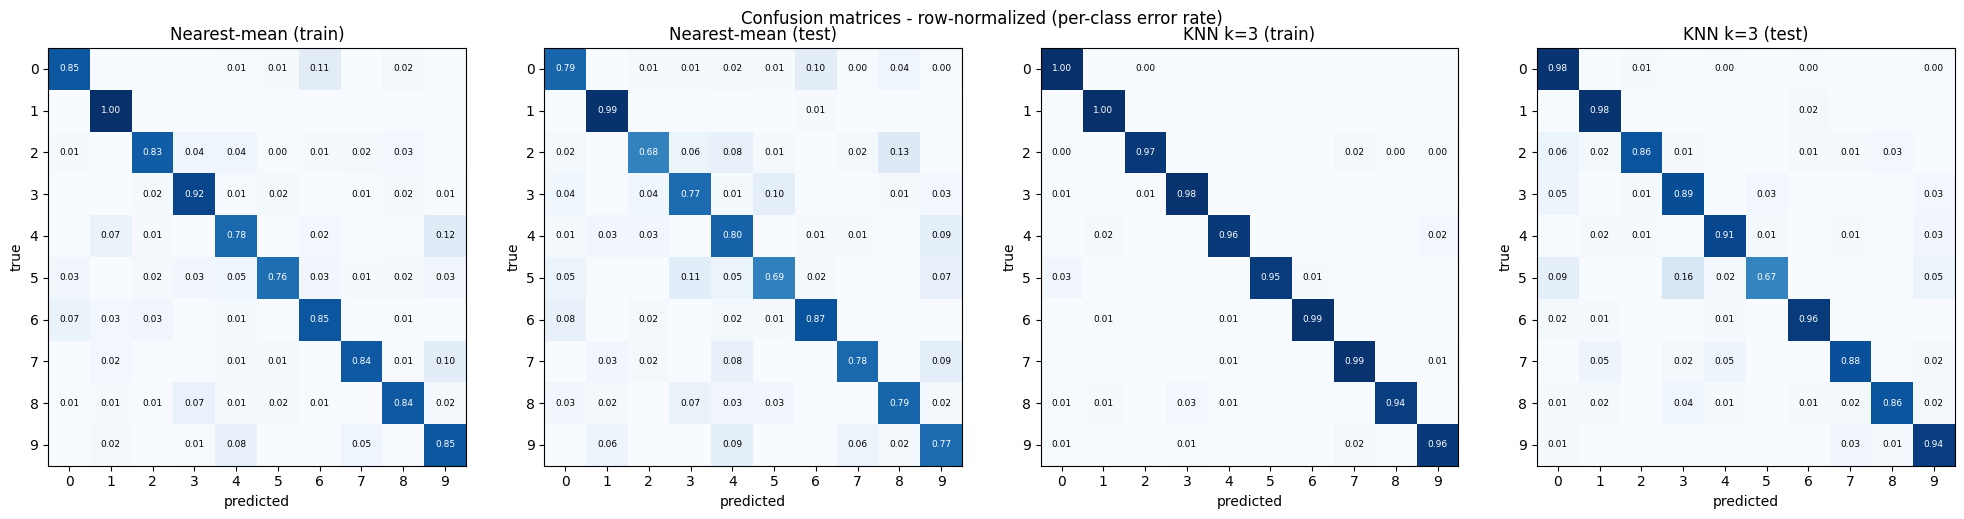

In [7]:
cm_nm_train = confusion_matrix(train_out, nm_train_pred)
cm_nm_test = confusion_matrix(test_out, nm_test_pred)
cm_knn_train = confusion_matrix(train_out, knn_train_pred)
cm_knn_test = confusion_matrix(test_out, knn_test_pred)

def plot_cms(cms, titles, suptitle, normalize=False):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, cm, title in zip(axes, cms, titles):
        mat = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalize else cm
        im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1 if normalize else None)
        ax.set_xticks(range(10)); ax.set_yticks(range(10))
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
        ax.set_title(title)
        for i in range(10):
            for j in range(10):
                if cm[i, j] > 0:
                    val = f'{mat[i,j]:.2f}' if normalize else str(cm[i, j])
                    thresh = 0.5 if normalize else cm.max() * 0.5
                    ax.text(j, i, val, ha='center', va='center',
                             color='white' if mat[i,j] > thresh else 'black', fontsize=6.5)
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()

cms = [cm_nm_train, cm_nm_test, cm_knn_train, cm_knn_test]
titles = ['Nearest-mean (train)', 'Nearest-mean (test)', 'KNN k=3 (train)', 'KNN k=3 (test)']
plot_cms(cms, titles, 'Confusion matrices - raw counts')
plot_cms(cms, titles, 'Confusion matrices - row-normalized (per-class error rate)', normalize=True)

In [8]:
def top_confused_pairs(cm, k=5):
    seen, scored = set(), []
    for i in range(10):
        for j in range(10):
            if i != j and (j, i) not in seen:
                seen.add((i, j))
                scored.append((cm[i, j] + cm[j, i], i, j))
    scored.sort(reverse=True)
    return scored[:k]

print("Predicted from 1.1 (closest centroids):", [(i, j) for _, i, j in predicted_pairs])
print("Actually most confused - Nearest-mean (test):", [(i, j) for _, i, j in top_confused_pairs(cm_nm_test)])
print("Actually most confused - KNN (test):", [(i, j) for _, i, j in top_confused_pairs(cm_knn_test)])

Predicted from 1.1 (closest centroids): [(7, 9), (4, 9), (3, 5), (8, 9), (5, 6)]
Actually most confused - Nearest-mean (test): [(0, 6), (4, 9), (3, 5), (2, 8), (0, 8)]
Actually most confused - KNN (test): [(3, 5), (0, 2), (0, 5), (7, 9), (4, 7)]
